# 🎵 Notebook 2: Audio Preprocessing
## Personalized Music Recommender System
### Converting Raw Audio → Mel Spectrogram Patch Tensors for the Audio Transformer

---

> **Notebook 2 of 9** | Prerequisites: Notebook 1 complete, `subset_50.csv` exists, audio files present.

---

### What This Notebook Builds

```
Raw MP3/WAV  →  Waveform  →  STFT  →  Mel Spectrogram  →  Log-Mel  →  Z-Norm  →  Patches  →  .npy
               (numpy)                 (64 mel bins)      (dB)       (μ=0,σ=1)  (64×256)   (saved)
```

**Output shape per song:** `(N_patches, patch_h, patch_w)` where default target is `(64, 16, 16)` 
— or equivalently a flattened spectrogram grid of shape `(64, 256)` for the transformer.

**Why this matters:**  
The Audio Transformer expects fixed-length sequences of 2-D patches — the same idea as Vision Transformer (ViT) but applied to mel spectrograms instead of images. Each patch becomes one "token" in the transformer sequence.

---
## 📐 Mathematical Background

### 2.1 — Discrete Fourier Transform (DFT)

For a discrete signal `x[n]` of length `N`, the DFT computes:

$$X[k] = \sum_{n=0}^{N-1} x[n] \cdot e^{-j2\pi kn/N}, \quad k = 0, 1, ..., N-1$$

`|X[k]|` gives the **amplitude** of frequency bin `k`.  
`angle(X[k])` gives the **phase**.  

The Fast Fourier Transform (FFT) computes the same thing in O(N log N) instead of O(N²).

### 2.2 — Short-Time Fourier Transform (STFT)

Audio is non-stationary (frequencies change over time). STFT applies the DFT to short overlapping windows:

$$\text{STFT}(m, k) = \sum_{n} x[n] \cdot w[n - m \cdot H] \cdot e^{-j2\pi kn/N_{fft}}$$

- `w[n]` — window function (Hann window: smooth edges to reduce spectral leakage)
- `m` — frame index (time axis)
- `H` — hop length (stride between windows)
- `N_fft` — FFT size (frequency resolution)

**Result:** A 2-D complex matrix of shape `(N_fft//2 + 1, T_frames)` — the spectrogram.

### 2.3 — Mel Scale

Human hearing is logarithmic in frequency. The mel scale approximates this:

$$m = 2595 \cdot \log_{10}\left(1 + \frac{f}{700}\right)$$

A mel filterbank projects the linear frequency axis onto `n_mels` perceptually-spaced bins using triangular filters. This gives a mel spectrogram of shape `(n_mels, T_frames)`.

### 2.4 — Log-Mel Conversion

Raw mel power values span many orders of magnitude. Log compression stabilizes training:

$$S_{log}[i,t] = 10 \cdot \log_{10}(\max(S[i,t], \epsilon))$$

This converts power (watts) to decibels (dB) — matching how loudness is perceived.

### 2.5 — Why Patching Works for Transformers

A mel spectrogram of shape `(64, 256)` (64 mel bins × 256 time frames) contains 16,384 values.  
Feeding every pixel as a separate token would create sequences of length 16,384 — computationally impossible.

Instead, we divide it into patches of size `(patch_h, patch_w)` and flatten each patch:

```
Spectrogram:  (64, 256)
Patch size:   (16, 16)
Patches:      (64/16) × (256/16) = 4 × 16 = 64 patches
Each patch:   16×16 = 256 values (the embedding input dimension)
Final input:  (64 patches, 256 values) → projected to (64, embedding_dim=128)
```

Attention complexity is O(T²) where T=64 patches — tractable even on 8GB GPU.

---
## ⚙️ Section 2.1 — Environment Setup and Imports

In [1]:
# ─────────────────────────────────────────────────────────────
# CELL 2.1 — IMPORTS AND GLOBAL CONFIG
# ─────────────────────────────────────────────────────────────
# Run this cell first. It installs missing packages if needed
# and sets all global hyperparameters in one place.

import sys
import subprocess

# Install librosa if not present
try:
    import librosa
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'librosa', '-q'])
    import librosa

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from tqdm.notebook import tqdm
import IPython.display as ipd
import librosa
import librosa.display

warnings.filterwarnings('ignore')

# ── Global Paths ──────────────────────────────────────────────
BASE_DIR = Path("../")
AUDIO_DIR   = BASE_DIR /'data'/ 'raw' / 'audio'
SUBSET_CSV  = BASE_DIR / 'subsets' / 'subset_50.csv'
PROC_AUDIO  = BASE_DIR /'data'/ 'processed' / 'mel_spectrograms'
FIGURES_DIR = BASE_DIR / 'figures' / 'audio'

PROC_AUDIO.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ── Audio Hyperparameters ─────────────────────────────────────
# These are tuned for 8GB GPU + lightweight transformer.
# Change ONLY at the top level here — all cells read from these.

SAMPLE_RATE    = 22050   # Hz. Standard for music analysis. Nyquist = 11025 Hz.
DURATION_S     = 30      # Seconds to keep per song (first 30s = hook + verse)
N_FFT         = 1024    # FFT window size. Frequency resolution = SR/N_FFT = 21.5 Hz/bin.
HOP_LENGTH    = 512     # Stride between windows. Time resolution = HOP/SR = 23.2 ms/frame.
N_MELS        = 64      # Number of mel frequency bins. Enough for music genre/mood.
F_MIN         = 20      # Minimum frequency (Hz). Below human hearing floor.
F_MAX         = 8000    # Maximum frequency (Hz). Covers most music fundamental content.

# Target spectrogram shape after fixed-length truncation/padding
# T_FRAMES = DURATION_S * SAMPLE_RATE / HOP_LENGTH
T_FRAMES_TARGET = 1292  # ≈ floor(30 * 22050 / 512) + 1

# Patch extraction parameters
PATCH_H = 16   # Height of each patch (along mel axis)
PATCH_W = 16   # Width of each patch  (along time axis)

# After patching: spectrogram (64, 1280) → using T=1280 (padded to divisible by 16)
# Patches: (64/16) × (1280/16) = 4 × 80 = 320 patches
# But we will use a cropped T=256 for ultra-lightweight experiments:
T_FRAMES_CROP  = 256   # Use only first 256 time frames (≈ 3 seconds)
# This gives: (64/16) × (256/16) = 4 × 16 = 64 patches per song
N_PATCHES_EXPECTED = (N_MELS // PATCH_H) * (T_FRAMES_CROP // PATCH_W)  # = 64
PATCH_DIM      = PATCH_H * PATCH_W  # = 256 (flattened patch size)
EMBED_DIM = 128

N_WORKERS = max(4, os.cpu_count() // 2)

print("=" * 55)
print("AUDIO PREPROCESSING CONFIG")
print("=" * 55)
print(f"Sample rate        : {SAMPLE_RATE} Hz")
print(f"Duration kept      : {DURATION_S} s")
print(f"N_FFT              : {N_FFT}")
print(f"Hop length         : {HOP_LENGTH} ({HOP_LENGTH/SAMPLE_RATE*1000:.1f} ms/frame)")
print(f"Mel bins (N_MELS)  : {N_MELS}")
print(f"Freq range         : {F_MIN}–{F_MAX} Hz")
print(f"T_FRAMES_CROP      : {T_FRAMES_CROP}  (spectrogram width used)")
print(f"Patch size         : ({PATCH_H}, {PATCH_W})")
print(f"N_PATCHES/song     : {N_PATCHES_EXPECTED}")
print(f"Patch dim (flat)   : {PATCH_DIM}")
print(f"Final tensor/song  : ({N_PATCHES_EXPECTED}, {PATCH_DIM})")
print()
print(f"Memory/song (float32): {N_PATCHES_EXPECTED * PATCH_DIM * 4 / 1024:.1f} KB")
print(f"Memory/50 songs     : {50 * N_PATCHES_EXPECTED * PATCH_DIM * 4 / 1024:.1f} KB  ← tiny")

AUDIO PREPROCESSING CONFIG
Sample rate        : 22050 Hz
Duration kept      : 30 s
N_FFT              : 1024
Hop length         : 512 (23.2 ms/frame)
Mel bins (N_MELS)  : 64
Freq range         : 20–8000 Hz
T_FRAMES_CROP      : 256  (spectrogram width used)
Patch size         : (16, 16)
N_PATCHES/song     : 64
Patch dim (flat)   : 256
Final tensor/song  : (64, 256)

Memory/song (float32): 64.0 KB
Memory/50 songs     : 3200.0 KB  ← tiny


---
## 🎧 Section 2.2 — Load Subset and Inspect One Song

Before batch processing, we always inspect a single example manually.
This is the "unit test" philosophy of preprocessing: verify correctness on one,
then loop.

In [2]:
# ─────────────────────────────────────────────────────────────
# CELL 2.2 — LOAD SUBSET CSV
# ─────────────────────────────────────────────────────────────

assert SUBSET_CSV.exists(), f"❌ subset_50.csv not found at {SUBSET_CSV}. Run Notebook 1 first."

df = pd.read_csv(SUBSET_CSV)
print(f"✅ Loaded subset: {len(df)} songs")
print(f"   Columns: {list(df.columns)}")
print()
display(df.head(3))

✅ Loaded subset: 10000 songs
   Columns: ['id', 'spotify_id', 'popularity', 'release', 'danceability', 'energy', 'key', 'mode', 'valence', 'tempo', 'duration_ms', 'artist', 'title', 'album_name', 'genre', 'year', 'decade', 'has_lyrics', 'has_audio', 'has_visual', 'completeness']



,id,spotify_id,popularity,release,danceability,energy,key,mode,valence,tempo,...,artist,title,album_name,genre,year,decade,has_lyrics,has_audio,has_visual,completeness
0,lUJHN9keOtaNGCYK,5sFEbn2q1dI0xO06BKkcH1,40.0,1013,0.639,0.512,8.0,0.0,0.598,127.451,...,Los Espíritus,noches de verano,Los Espíritus,"latin,rock,psychedelic rock",1013,1010s,True,True,True,3
1,3MEb9LZbB80nQ1a8,7fAa9rz4UmwuB4AGh50Gmp,29.0,1928,0.693,0.182,5.0,0.0,0.588,116.508,...,Louis Armstrong,St. James Infirmary,The Complete Hot Five And Hot Seven Recordings...,"jazz,blues",1928,1920s,True,True,True,3
2,RbaDhF3EoczkLKJl,0ndEbK6LnERIPBG6t4gXDX,38.0,1933,0.485,0.177,7.0,1.0,0.253,88.411,...,Billie Holiday,The Man I Love,Lady Day: The Complete Billie Holiday On Colum...,"jazz,blues,vocal jazz",1933,1930s,True,True,True,3


✅ Loading: ..\data\raw\audio\lUJHN9keOtaNGCYK.wav
   Waveform shape : (661500,)   ← (N_samples,)
   Sample rate    : 22050 Hz
   Duration       : 30.00 s
   dtype          : float32
   Value range    : [-0.958, 0.954]


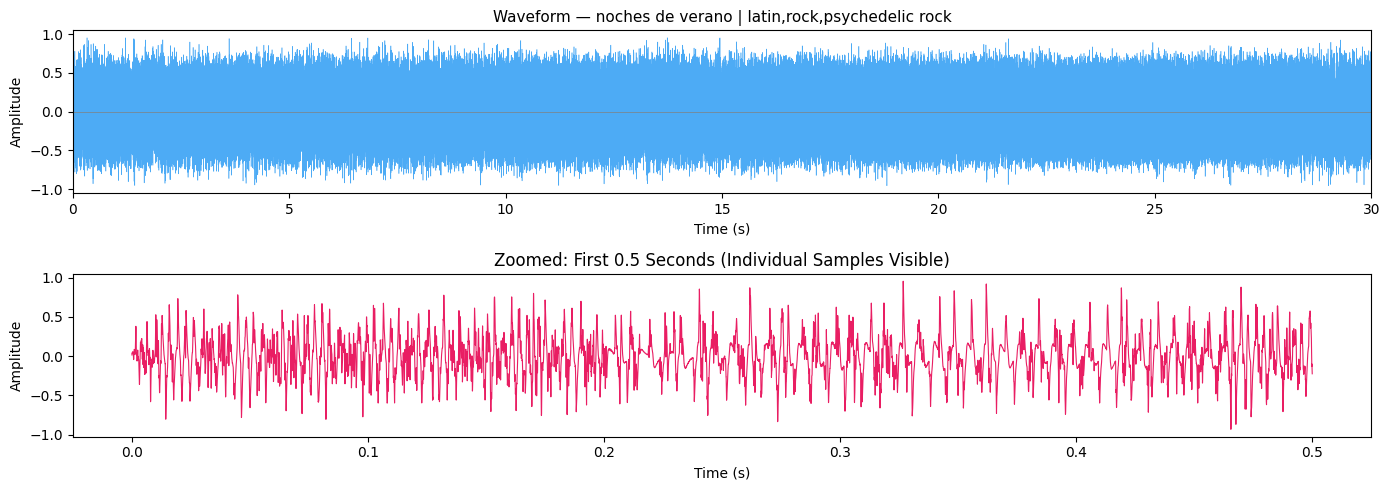

▶️  Playing audio (first 10 s):



✅ Waveform sanity checks:
   ndim=1 ✓  dtype=float32 ✓  no NaN ✓  no Inf ✓


In [3]:
# ─────────────────────────────────────────────────────────────
# CELL 2.3 — SINGLE SONG INSPECTION: WAVEFORM
# ─────────────────────────────────────────────────────────────
# Tensor shape walk-through for song index 0.
# Change INDEX to inspect any other song.

INDEX = 0
row   = df.iloc[INDEX]

# Build the audio file path — adjust 'audio_path' column name if yours differs
audio_col = 'audio_path' if 'audio_path' in df.columns else 'id'

# Try common path patterns
candidate_paths = [
    Path(row.get('audio_path', '')),
    AUDIO_DIR / f"{row['id']}.mp3",
    AUDIO_DIR / f"{row['id']}.wav",
    AUDIO_DIR / f"{row['id']}.flac",
]
audio_file = next((p for p in candidate_paths if p.is_file()), None)

if audio_file is None:
    print("⚠️  Audio file not found. Using a synthetic sine wave for demonstration.")
    print("   Place audio files in:", AUDIO_DIR)
    SR_DEMO = SAMPLE_RATE
    t = np.linspace(0, 5.0, int(5.0 * SR_DEMO), endpoint=False)
    # Synthetic: mix of 440 Hz (A4) + 523 Hz (C5) + amplitude envelope
    y = 0.5 * np.sin(2 * np.pi * 440 * t) + 0.3 * np.sin(2 * np.pi * 523 * t)
    y = y * np.exp(-t / 5.0)  # decay envelope
    sr = SR_DEMO
    print(f"   Synthetic waveform shape: {y.shape}  dtype: {y.dtype}")
else:
    print(f"✅ Loading: {audio_file}")
    # librosa.load returns (waveform_array, sample_rate)
    # mono=True → averages stereo channels → shape (N_samples,)
    # sr=SAMPLE_RATE → resamples on the fly if original SR differs
    # duration=DURATION_S → loads only first 30 seconds
    y, sr = librosa.load(audio_file, sr=SAMPLE_RATE, mono=True, duration=DURATION_S)
    print(f"   Waveform shape : {y.shape}   ← (N_samples,)")
    print(f"   Sample rate    : {sr} Hz")
    print(f"   Duration       : {len(y)/sr:.2f} s")
    print(f"   dtype          : {y.dtype}")
    print(f"   Value range    : [{y.min():.3f}, {y.max():.3f}]")

# ── Waveform Visualization ────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 5))

# Full waveform
time_axis = np.linspace(0, len(y)/sr, len(y))
axes[0].plot(time_axis, y, color='#2196F3', linewidth=0.4, alpha=0.8)
axes[0].set_title(f'Waveform — {row.get("title", row["id"])} | {row.get("genre", "?")}',fontsize=11)
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Amplitude')
axes[0].axhline(0, color='gray', linewidth=0.5)
axes[0].set_xlim(0, len(y)/sr)

# Zoomed — first 0.5 seconds to see individual samples
n_zoom = int(0.5 * sr)
axes[1].plot(time_axis[:n_zoom], y[:n_zoom], color='#E91E63', linewidth=0.8)
axes[1].set_title('Zoomed: First 0.5 Seconds (Individual Samples Visible)')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Amplitude')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig_waveform.png', dpi=120)
plt.show()

# ── Play Audio in Notebook (if file exists) ───────────────────
if audio_file is not None:
    print("▶️  Playing audio (first 10 s):")
    ipd.display(ipd.Audio(y[:10*sr], rate=sr))

print()
print("✅ Waveform sanity checks:")
assert y.ndim == 1, "Expected 1-D mono waveform"
assert y.dtype == np.float32, f"Expected float32, got {y.dtype}"
assert not np.any(np.isnan(y)), "NaN values in waveform!"
assert not np.any(np.isinf(y)), "Inf values in waveform!"
print(f"   ndim=1 ✓  dtype=float32 ✓  no NaN ✓  no Inf ✓")

---
## 📊 Section 2.3 — STFT and Mel Spectrogram

We compute the **mel spectrogram** step-by-step, printing shapes at each stage so you can see exactly what librosa is doing internally.

In [4]:
# ─────────────────────────────────────────────────────────────
# CELL 2.4 — STFT → MEL SPECTROGRAM → LOG → NORMALIZE
# ─────────────────────────────────────────────────────────────
# Step-by-step with shape printing at every stage.

print("STAGE 1: Short-Time Fourier Transform (STFT)")
print("-" * 48)
# D is complex matrix: shape (N_FFT//2 + 1, T_frames)
D = librosa.stft(y, n_fft=N_FFT, hop_length=HOP_LENGTH, window='hann')
print(f"  STFT output shape  : {D.shape}  ← (freq_bins, time_frames)")
print(f"  Freq bins          : {D.shape[0]}  = N_FFT//2 + 1 = {N_FFT}//2 + 1")
print(f"  Time frames        : {D.shape[1]}  ≈ duration×SR/hop = {DURATION_S}×{SAMPLE_RATE}/{HOP_LENGTH}")
print(f"  dtype              : {D.dtype}  (complex64)")
print()

print("STAGE 2: Power Spectrogram (|D|²)")
print("-" * 48)
# Convert complex STFT to real power: |D|²
S_power = np.abs(D) ** 2
print(f"  Power spectrogram  : {S_power.shape}  ← (freq_bins, time_frames)")
print(f"  dtype              : {S_power.dtype}")
print(f"  Value range        : [{S_power.min():.2e}, {S_power.max():.2e}]")
print()

print("STAGE 3: Mel Filterbank Projection")
print("-" * 48)
# librosa.feature.melspectrogram applies mel filterbank and returns power mel spectrogram
S_mel = librosa.feature.melspectrogram(
    S=S_power, sr=sr, n_mels=N_MELS, fmin=F_MIN, fmax=F_MAX
)
print(f"  Mel spectrogram    : {S_mel.shape}  ← (n_mels, time_frames)")
print(f"  n_mels             : {S_mel.shape[0]}")
print(f"  Value range        : [{S_mel.min():.2e}, {S_mel.max():.2e}]")
print()

print("STAGE 4: Log-Mel (dB conversion)")
print("-" * 48)
# Convert power to dB: 10 * log10(S + eps)
S_db = librosa.power_to_db(S_mel, ref=np.max)
print(f"  Log-mel shape      : {S_db.shape}  ← same shape, values now in dB")
print(f"  Value range        : [{S_db.min():.1f}, {S_db.max():.1f}] dB")
print(f"  (ref=np.max → max value becomes 0 dB, rest are negative)")
print()

print("STAGE 5: Fixed-Length Crop/Pad to T_FRAMES_CROP")
print("-" * 48)
# We need a fixed time dimension for batching
T_actual = S_db.shape[1]
if T_actual >= T_FRAMES_CROP:
    S_fixed = S_db[:, :T_FRAMES_CROP]  # Crop
    print(f"  Cropped: {T_actual} → {T_FRAMES_CROP} frames (took first {T_FRAMES_CROP})")
else:
    pad_width = T_FRAMES_CROP - T_actual
    S_fixed = np.pad(S_db, ((0, 0), (0, pad_width)), mode='constant', constant_values=S_db.min())
    print(f"  Padded: {T_actual} → {T_FRAMES_CROP} frames (padded with min dB = {S_db.min():.1f})")
print(f"  Fixed shape        : {S_fixed.shape}  ← (N_MELS={N_MELS}, T={T_FRAMES_CROP})")
print()

print("STAGE 6: Z-Score Normalization")
print("-" * 48)
# Per-spectrogram normalization: mean=0, std=1
# This makes training more stable (gradients don't explode)
mu  = S_fixed.mean()
std = S_fixed.std() + 1e-8  # epsilon prevents division by zero
S_norm = (S_fixed - mu) / std
print(f"  Before: mean={mu:.3f}, std={std:.3f}")
print(f"  After:  mean={S_norm.mean():.5f}, std={S_norm.std():.5f}")
print(f"  Shape  : {S_norm.shape}  — ready for patch extraction")

# Sanity assertions
assert not np.any(np.isnan(S_norm)), "❌ NaN in normalized spectrogram!"
assert S_norm.shape == (N_MELS, T_FRAMES_CROP), f"Shape mismatch: {S_norm.shape}"
print(f"\n✅ Spectrogram verified: shape={S_norm.shape}, no NaN, normalized.")

STAGE 1: Short-Time Fourier Transform (STFT)
------------------------------------------------
  STFT output shape  : (513, 1292)  ← (freq_bins, time_frames)
  Freq bins          : 513  = N_FFT//2 + 1 = 1024//2 + 1
  Time frames        : 1292  ≈ duration×SR/hop = 30×22050/512
  dtype              : complex64  (complex64)

STAGE 2: Power Spectrogram (|D|²)
------------------------------------------------
  Power spectrogram  : (513, 1292)  ← (freq_bins, time_frames)
  dtype              : float32
  Value range        : [8.22e-17, 2.06e+04]

STAGE 3: Mel Filterbank Projection
------------------------------------------------
  Mel spectrogram    : (64, 1292)  ← (n_mels, time_frames)
  n_mels             : 64
  Value range        : [5.39e-05, 5.31e+02]

STAGE 4: Log-Mel (dB conversion)
------------------------------------------------
  Log-mel shape      : (64, 1292)  ← same shape, values now in dB
  Value range        : [-69.9, 0.0] dB
  (ref=np.max → max value becomes 0 dB, rest are negat

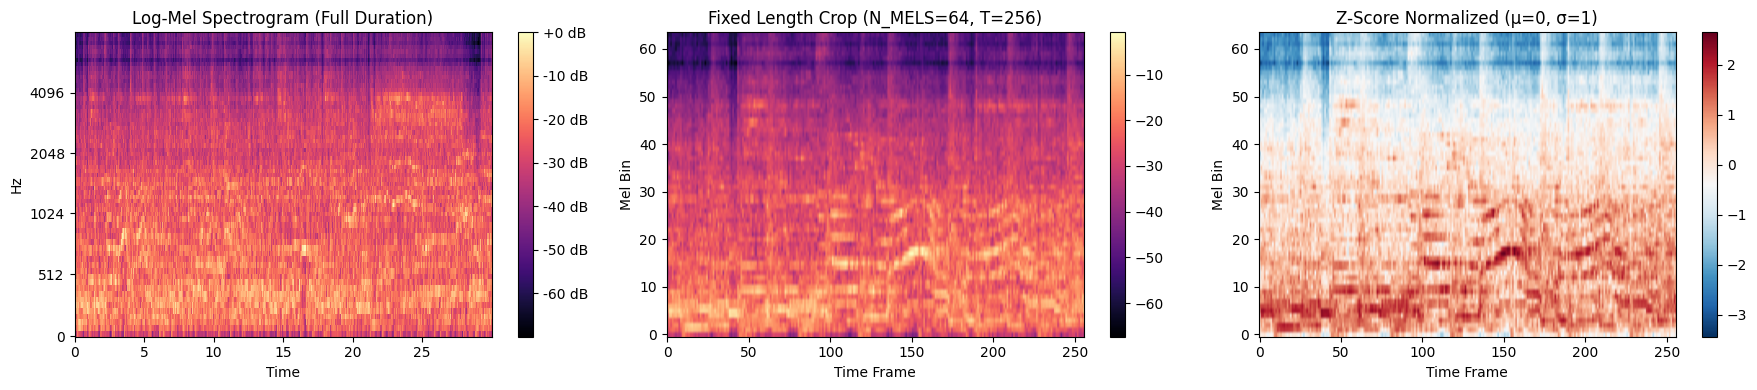

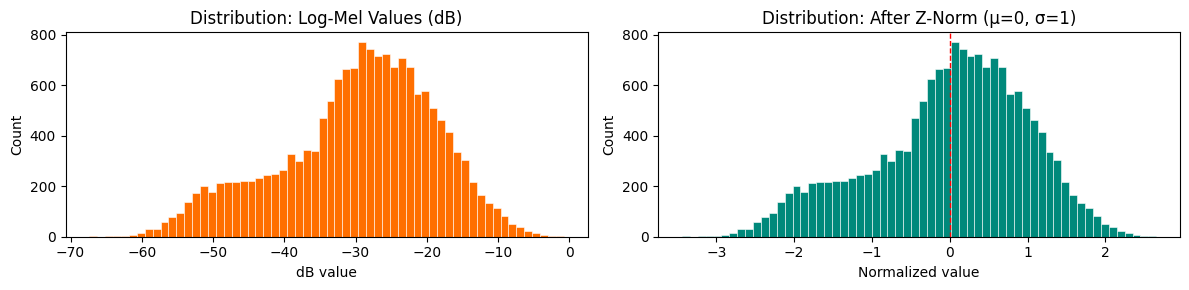

✅ Saved visualization figures.


In [5]:
# ─────────────────────────────────────────────────────────────
# CELL 2.5 — VISUALIZE SPECTROGRAM PIPELINE
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# 1. Raw power spectrogram (dB)
img1 = librosa.display.specshow(
    S_db, sr=sr, hop_length=HOP_LENGTH, x_axis='time', y_axis='mel',
    fmin=F_MIN, fmax=F_MAX, ax=axes[0], cmap='magma'
)
axes[0].set_title('Log-Mel Spectrogram (Full Duration)')
fig.colorbar(img1, ax=axes[0], format='%+2.0f dB')

# 2. Fixed-length (cropped)
img2 = axes[1].imshow(S_fixed, aspect='auto', origin='lower', cmap='magma')
axes[1].set_title(f'Fixed Length Crop (N_MELS={N_MELS}, T={T_FRAMES_CROP})')
axes[1].set_xlabel('Time Frame')
axes[1].set_ylabel('Mel Bin')
fig.colorbar(img2, ax=axes[1])

# 3. Normalized
img3 = axes[2].imshow(S_norm, aspect='auto', origin='lower', cmap='RdBu_r')
axes[2].set_title(f'Z-Score Normalized (μ=0, σ=1)')
axes[2].set_xlabel('Time Frame')
axes[2].set_ylabel('Mel Bin')
fig.colorbar(img3, ax=axes[2])

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig_mel_pipeline.png', dpi=120, bbox_inches='tight')
plt.show()

# Histogram — before vs after normalization
fig2, axes2 = plt.subplots(1, 2, figsize=(12, 3))
axes2[0].hist(S_fixed.flatten(), bins=60, color='#FF6F00', edgecolor='white', linewidth=0.4)
axes2[0].set_title('Distribution: Log-Mel Values (dB)')
axes2[0].set_xlabel('dB value')
axes2[0].set_ylabel('Count')

axes2[1].hist(S_norm.flatten(), bins=60, color='#00897B', edgecolor='white', linewidth=0.4)
axes2[1].set_title('Distribution: After Z-Norm (μ=0, σ=1)')
axes2[1].set_xlabel('Normalized value')
axes2[1].set_ylabel('Count')
axes2[1].axvline(0, color='red', linestyle='--', linewidth=1)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig_normalization_hist.png', dpi=120)
plt.show()
print("✅ Saved visualization figures.")

---
## 🧩 Section 2.4 — Manual Patch Extraction

We implement patch extraction **from scratch** — no `einops`, no `unfold` — to understand exactly what happens.

```
S_norm:  (64, 256)     ← mel bins × time frames
Patches: (4, 16, 16, 16)  ← (n_rows, n_cols, patch_h, patch_w)
Reshaped: (64, 256)      ← (n_patches, patch_dim) — sequence for transformer
```

In [6]:
# ─────────────────────────────────────────────────────────────
# CELL 2.6 — PATCH EXTRACTION (FROM SCRATCH)
# ─────────────────────────────────────────────────────────────

def extract_patches(spectrogram: np.ndarray, patch_h: int, patch_w: int) -> np.ndarray:
    """
    Extract non-overlapping patches from a 2-D spectrogram.
    
    Args:
        spectrogram: np.ndarray of shape (H, W) — (n_mels, T_frames)
        patch_h:     int — height of each patch
        patch_w:     int — width of each patch
    
    Returns:
        patches: np.ndarray of shape (N_patches, patch_h * patch_w)
                 where N_patches = (H // patch_h) * (W // patch_w)
    
    Mathematical view:
        For a spectrogram of shape (H, W) divided into non-overlapping
        patches of size (ph, pw):
            n_rows = H // ph    (number of patches along mel axis)
            n_cols = W // pw    (number of patches along time axis)
            N_patches = n_rows × n_cols
            Each patch: flattened to (ph × pw,) vector
    """
    H, W = spectrogram.shape
    assert H % patch_h == 0, f"H={H} not divisible by patch_h={patch_h}"
    assert W % patch_w == 0, f"W={W} not divisible by patch_w={patch_w}"
    
    n_rows = H // patch_h
    n_cols = W // patch_w
    
    patches = []
    for r in range(n_rows):
        for c in range(n_cols):
            # Extract patch: rows [r*ph : (r+1)*ph], cols [c*pw : (c+1)*pw]
            patch = spectrogram[
                r * patch_h : (r + 1) * patch_h,
                c * patch_w : (c + 1) * patch_w
            ]
            # Flatten: (patch_h, patch_w) → (patch_h * patch_w,)
            patches.append(patch.flatten())
    
    return np.array(patches, dtype=np.float32)  # (N_patches, patch_dim)


# ── Apply to our example ──────────────────────────────────────
print("Patch Extraction:")
print(f"  Input spectrogram : {S_norm.shape}")

patches = extract_patches(S_norm, PATCH_H, PATCH_W)

print(f"  n_rows = {N_MELS} // {PATCH_H} = {N_MELS // PATCH_H}")
print(f"  n_cols = {T_FRAMES_CROP} // {PATCH_W} = {T_FRAMES_CROP // PATCH_W}")
print(f"  N_patches = {N_MELS // PATCH_H} × {T_FRAMES_CROP // PATCH_W} = {N_PATCHES_EXPECTED}")
print(f"  Patch dim = {PATCH_H} × {PATCH_W} = {PATCH_DIM}")
print(f"  Output shape : {patches.shape}  ← (N_patches, patch_dim)")
print(f"  dtype        : {patches.dtype}")
print()

# Sanity checks
assert patches.shape == (N_PATCHES_EXPECTED, PATCH_DIM), \
    f"❌ Expected ({N_PATCHES_EXPECTED}, {PATCH_DIM}), got {patches.shape}"
assert not np.any(np.isnan(patches)), "❌ NaN in patches!"
print("✅ Patch extraction verified.")
print()
print(f"  Transformer will see: sequence of {N_PATCHES_EXPECTED} tokens, each dim {PATCH_DIM}")
print(f"  A Linear(patch_dim, embed_dim) layer → ({N_PATCHES_EXPECTED}, 128) per song")


# ── Reconstruction sanity check ───────────────────────────────
# Reconstruct the spectrogram from patches to verify no data loss
def reconstruct_from_patches(patches, H, W, patch_h, patch_w):
    """Reverse of extract_patches — verifies patches can recover original."""
    recon = np.zeros((H, W), dtype=np.float32)
    n_rows = H // patch_h
    n_cols = W // patch_w
    for idx, (r, c) in enumerate((r, c) for r in range(n_rows) for c in range(n_cols)):
        recon[r*patch_h:(r+1)*patch_h, c*patch_w:(c+1)*patch_w] = \
            patches[idx].reshape(patch_h, patch_w)
    return recon

recon = reconstruct_from_patches(patches, N_MELS, T_FRAMES_CROP, PATCH_H, PATCH_W)
max_err = np.max(np.abs(recon - S_norm))
print(f"  Reconstruction max error: {max_err:.2e}  (should be ~0)")
assert max_err < 1e-5, f"❌ Reconstruction error too large: {max_err}"
print("✅ Reconstruction verified — patches are lossless.")

Patch Extraction:
  Input spectrogram : (64, 256)
  n_rows = 64 // 16 = 4
  n_cols = 256 // 16 = 16
  N_patches = 4 × 16 = 64
  Patch dim = 16 × 16 = 256
  Output shape : (64, 256)  ← (N_patches, patch_dim)
  dtype        : float32

✅ Patch extraction verified.

  Transformer will see: sequence of 64 tokens, each dim 256
  A Linear(patch_dim, embed_dim) layer → (64, 128) per song
  Reconstruction max error: 0.00e+00  (should be ~0)
✅ Reconstruction verified — patches are lossless.


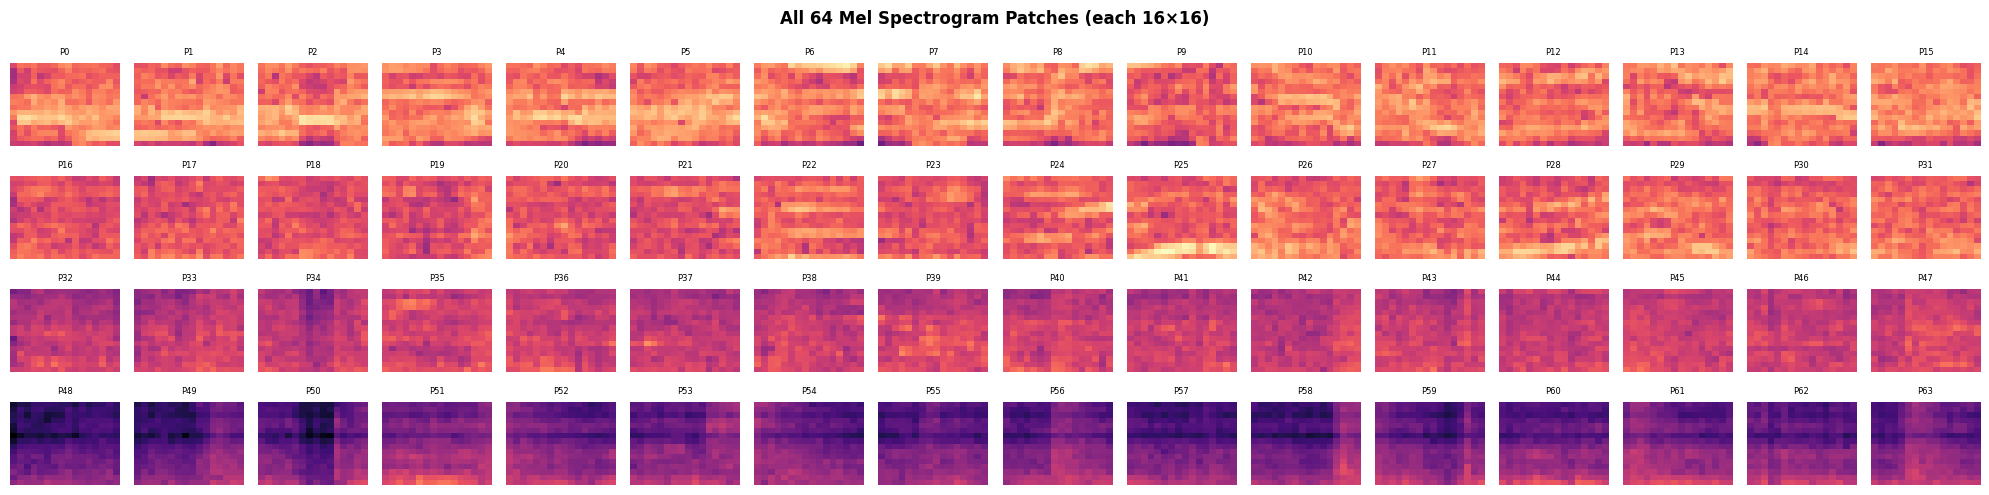

✅ Patch grid saved.
   Each patch: 16×16 = 256 values → will be linearly projected to embed_dim=128


In [7]:
# ─────────────────────────────────────────────────────────────
# CELL 2.7 — PATCH VISUALIZATION
# ─────────────────────────────────────────────────────────────

n_rows_viz = N_MELS // PATCH_H      # = 4
n_cols_viz = T_FRAMES_CROP // PATCH_W  # = 16

fig, axes = plt.subplots(n_rows_viz, n_cols_viz, figsize=(20, 5))
fig.suptitle(f'All {N_PATCHES_EXPECTED} Mel Spectrogram Patches (each {PATCH_H}×{PATCH_W})',
             fontsize=12, fontweight='bold')

for idx, ax in enumerate(axes.flatten()):
    patch_img = patches[idx].reshape(PATCH_H, PATCH_W)
    ax.imshow(patch_img, aspect='auto', origin='lower', cmap='magma',
              vmin=patches.min(), vmax=patches.max())
    ax.axis('off')
    ax.set_title(f'P{idx}', fontsize=6)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig_patches_grid.png', dpi=100, bbox_inches='tight')
plt.show()
print("✅ Patch grid saved.")
print(f"   Each patch: {PATCH_H}×{PATCH_W} = {PATCH_DIM} values → will be linearly projected to embed_dim=128")

---
## 🏭 Section 2.5 — Full Preprocessing Pipeline Function

Now we encapsulate everything into a reusable function and run it across all 50 songs.

In [8]:
# ─────────────────────────────────────────────────────────────
# CELL 2.8 — PREPROCESSING FUNCTION
# ─────────────────────────────────────────────────────────────

def preprocess_audio(audio_path: str,
                     sample_rate: int = SAMPLE_RATE,
                     duration: float = DURATION_S,
                     n_fft: int = N_FFT,
                     hop_length: int = HOP_LENGTH,
                     n_mels: int = N_MELS,
                     f_min: float = F_MIN,
                     f_max: float = F_MAX,
                     t_crop: int = T_FRAMES_CROP,
                     patch_h: int = PATCH_H,
                     patch_w: int = PATCH_W) -> np.ndarray:
    """
    Full audio preprocessing pipeline.
    
    Steps:
        1. Load waveform (mono, resampled, duration-clipped)
        2. Compute mel spectrogram
        3. Log-mel (dB) conversion
        4. Fixed-length crop/pad
        5. Z-score normalization
        6. Patch extraction
    
    Returns:
        patches: np.ndarray, shape (N_patches, patch_h * patch_w), dtype float32
        Returns None on failure (corrupted file, missing file).
    """
    try:
        # Step 1: Load
        y, sr = librosa.load(audio_path,sr=SAMPLE_RATE,res_type='soxr_hq')
        
        # Step 2: Mel spectrogram (combines STFT + mel filterbank internally)
        S_mel = librosa.feature.melspectrogram(
            y=y, sr=sr,
            n_fft=n_fft, hop_length=hop_length,
            n_mels=n_mels, fmin=f_min, fmax=f_max
        )
        
        # Step 3: Log-mel
        S_db = librosa.power_to_db(S_mel, ref=np.max)
        
        # Step 4: Fixed-length
        T = S_db.shape[1]
        if T >= t_crop:
            S_fixed = S_db[:, :t_crop]
        else:
            pad = t_crop - T
            S_fixed = np.pad(S_db, ((0,0),(0,pad)), mode='constant',
                             constant_values=S_db.min())
        
        # Step 5: Z-norm
        mu = S_fixed.mean()
        std = S_fixed.std() + 1e-8
        S_norm = (S_fixed - mu) / std
        S_norm = S_norm.astype(np.float32)
        
        # Step 6: Patches
        patches = extract_patches(S_norm, patch_h, patch_w)
        
        return patches
    
    except Exception as e:
        print(f"  ⚠️  Error processing {audio_path}: {e}")
        return None


print("✅ Preprocessing function defined.")
print(f"   Expected output shape per song: ({N_PATCHES_EXPECTED}, {PATCH_DIM})")

✅ Preprocessing function defined.
   Expected output shape per song: (64, 256)


In [9]:
# ─────────────────────────────────────────────────────────────
# CELL 2.9 — BATCH PROCESS ALL SONGS → SINGLE MEMORY-MAPPED FILE
# ─────────────────────────────────────────────────────────────
# Precomputes ALL mel spectrogram patches once and stores them
# in a single memory-mapped .npy file (mel_all.npy).
#
# Why memory-mapped instead of per-song .npy files?
#   - One file open → no per-song file descriptor overhead
#   - DataLoader reads only the rows it needs via mmap_mode='r'
#   - Survives 100k+ songs without filling RAM
#
# Layout of mel_all.npy:
#   shape: (N_SONGS, N_PATCHES_EXPECTED, PATCH_DIM)
#   dtype: float32
#   row i corresponds to df.iloc[i]
#
# A companion index file (mel_index.json) maps song_id → row index
# so downstream notebooks can look up any song by ID.
import json
from concurrent.futures import ProcessPoolExecutor, as_completed
from concurrent.futures import ThreadPoolExecutor

print("=" * 55)
print("BATCH AUDIO PREPROCESSING")
print("=" * 55)
print(f"Songs to process : {len(df)}")
print(f"Output file      : {PROC_AUDIO / 'mel_all.npy'}")
print(f"Expected shape   : ({len(df)}, {N_PATCHES_EXPECTED}, {PATCH_DIM})")
print(f"Estimated size   : {len(df) * N_PATCHES_EXPECTED * PATCH_DIM * 4 / 1e6:.1f} MB")
print()

# ── Step 1: Resolve audio paths for every song ───────────────
# Build a list of (row_index, song_id, resolved_path_or_None)
# before touching the GPU or the mmap file.

path_records = []   # (i, song_id, Path | None)

for i, row in enumerate(df.itertuples(index=False)):
    id = str(row.id)
    candidates = [
        AUDIO_DIR / f"{id}.mp3",
        AUDIO_DIR / f"{id}.wav",
        AUDIO_DIR / f"{id}.flac",
    ]
    # also try an explicit audio_path column if it exists
    if hasattr(row, 'audio_path') and str(row.audio_path) not in ('', 'nan', 'MISSING'):
        candidates.append(Path(str(row.audio_path)))

    found = next((p for p in candidates if p.exists()), None)
    path_records.append((i, id, found))

n_found   = sum(1 for _, _, p in path_records if p is not None)
n_missing = len(path_records) - n_found
print(f"Audio files found   : {n_found}")
print(f"Audio files missing : {n_missing}")
print()

# ── Step 2: Create the memory-mapped output array ONCE ───────
# open_memmap with mode='w+' creates the file and zero-fills it.
# If the file already exists it will be overwritten — this is
# intentional so a re-run always produces a consistent file.

N_SONGS = len(df)

mel_mmap = np.lib.format.open_memmap(
    PROC_AUDIO / 'mel_all.npy',
    mode='w+',
    dtype='float32',
    shape=(N_SONGS, N_PATCHES_EXPECTED, PATCH_DIM),
)
print(f"✅ Memory-mapped file created: {mel_mmap.shape}  dtype={mel_mmap.dtype}")

# ── Step 3: Parallel preprocessing ───────────────────────────
# ProcessPoolExecutor spawns separate Python processes, bypassing
# the GIL. Each worker calls preprocess_audio(path_str) and
# returns (row_index, song_id, patches | None).
#
# max_workers=4 is conservative for an 8 GB GPU machine.
# librosa is CPU-bound so 4 workers ~ 4× speedup over serial.
# Increase to os.cpu_count() // 2 if you have many cores.

def _worker(args):
    """Thin wrapper so ProcessPoolExecutor can pickle the task."""
    row_idx, id, path = args
    if path is None:
        return row_idx, id, None, 'MISSING'
    try:
        patches = preprocess_audio(str(path))   # defined in Cell 2.6
        if patches is None:
            return row_idx, id, None, 'ERROR'
        return row_idx, id, patches, 'OK'
    except Exception as e:
        return row_idx, id, None, f'ERROR:{e}'


results = []   # list of dicts for the summary DataFrame

print("Processing...")
with ThreadPoolExecutor(max_workers=4) as executor:
    futures = {executor.submit(_worker, rec): rec for rec in path_records}

    for future in tqdm(as_completed(futures), total=len(futures), desc="Audio"):
        row_idx, id, patches, status = future.result()

        if status == 'OK' and patches is not None:
            # Write directly into the correct row of the mmap array.
            # This is the ONLY place we write — no per-song np.save.
            mel_mmap[row_idx] = patches

        results.append({'row_idx': row_idx, 'id': id, 'status': status})

# Flush all pending writes to disk before anything else reads the file.
mel_mmap.flush()
del mel_mmap   # release the mmap handle (file stays on disk)
print()
print("✅ mel_all.npy written and flushed.")

# ── Step 4: Save the song_id → row_index lookup ──────────────
# Downstream notebooks need to know which row belongs to which
# song without loading the full array. This tiny JSON does that.

id_to_row = {rec['id']: rec['row_idx'] for rec in results if rec['status'] == 'OK'}

index_path = PROC_AUDIO / 'mel_index.json'
with open(index_path, 'w') as f:
    json.dump(id_to_row, f)
print(f"✅ Index saved: {index_path}  ({len(id_to_row)} entries)")

# ── Step 5: Summary ───────────────────────────────────────────
df_results = pd.DataFrame(results)

print()
print("=" * 55)
print("SUMMARY")
print("=" * 55)
print(df_results['status'].value_counts().to_string())
print()
print(f"Successfully processed : {(df_results['status'] == 'OK').sum()}")
print(f"Missing audio files    : {(df_results['status'] == 'MISSING').sum()}")
print(f"Errors                 : {df_results['status'].str.startswith('ERROR').sum()}")

# ── Step 6: Verification read ─────────────────────────────────
# Re-open in read-only mode and spot-check the first OK row.
ok_rows = df_results[df_results['status'] == 'OK']
if len(ok_rows) > 0:
    verify_idx = ok_rows.iloc[0]['row_idx']
    verify_id  = ok_rows.iloc[0]['id']
    check = np.load(PROC_AUDIO / 'mel_all.npy', mmap_mode='r')
    patch = check[verify_idx]
    print()
    print(f"Verification (song '{verify_id}', row {verify_idx}):")
    print(f"  Shape  : {patch.shape}  expected ({N_PATCHES_EXPECTED}, {PATCH_DIM})")
    print(f"  dtype  : {patch.dtype}")
    print(f"  min/max: {patch.min():.3f} / {patch.max():.3f}")
    assert patch.shape == (N_PATCHES_EXPECTED, PATCH_DIM), "Shape mismatch!"
    assert not np.any(np.isnan(patch)), "NaN values found!"
    print("  ✅ Verification passed.")
    del check

BATCH AUDIO PREPROCESSING
Songs to process : 10000
Output file      : ..\data\processed\mel_spectrograms\mel_all.npy
Expected shape   : (10000, 64, 256)
Estimated size   : 655.4 MB

Audio files found   : 10000
Audio files missing : 0

✅ Memory-mapped file created: (10000, 64, 256)  dtype=float32
Processing...


Audio:   0%|          | 0/10000 [00:00<?, ?it/s]


✅ mel_all.npy written and flushed.
✅ Index saved: ..\data\processed\mel_spectrograms\mel_index.json  (10000 entries)

SUMMARY
status
OK    10000

Successfully processed : 10000
Missing audio files    : 0
Errors                 : 0

Verification (song 'jfzhRuGuLSLd2IIx', row 3):
  Shape  : (64, 256)  expected (64, 256)
  dtype  : float32
  min/max: -1.887 / 3.221
  ✅ Verification passed.


In [10]:
# ─────────────────────────────────────────────────────────────
# CELL 2.10 — VERIFICATION: LOAD mel_all.npy AND BATCH CHECK
# ─────────────────────────────────────────────────────────────
# Cell 2.9 now saves ONE memory-mapped file (mel_all.npy) with
# shape (N_SONGS, N_PATCHES_EXPECTED, PATCH_DIM) instead of
# one .npy per song.
#
# This cell verifies that file — not per-song files.
# It also loads mel_index.json to cross-check song ID coverage.

import json

MEL_ALL_PATH   = PROC_AUDIO / 'mel_all.npy'
MEL_INDEX_PATH = PROC_AUDIO / 'mel_index.json'
EMBED_DIM = 128
print("=" * 55)
print("VERIFICATION: mel_all.npy")
print("=" * 55)

# ── 1. File existence ─────────────────────────────────────────
assert MEL_ALL_PATH.exists(),   f"mel_all.npy not found at {MEL_ALL_PATH}"
assert MEL_INDEX_PATH.exists(), f"mel_index.json not found at {MEL_INDEX_PATH}"
print(f"✅ mel_all.npy   found : {MEL_ALL_PATH}")
print(f"✅ mel_index.json found : {MEL_INDEX_PATH}")
print()

# ── 2. Load the index ─────────────────────────────────────────
with open(MEL_INDEX_PATH) as f:
    mel_index = json.load(f)   # {song_id: row_index}

N_INDEXED = len(mel_index)
print(f"Index entries   : {N_INDEXED}")
print(f"Expected songs  : {len(df)}")
missing_from_index = [str(row.id) for row in df.itertuples()
                      if str(row.id) not in mel_index]
if missing_from_index:
    print(f"⚠️  Songs missing from index: {len(missing_from_index)}")
    print(f"   First 5: {missing_from_index[:5]}")
else:
    print(f"✅ All {N_INDEXED} songs present in index")
print()

# ── 3. Shape and dtype check ──────────────────────────────────
# Open as mmap — no RAM cost even at 100k songs
batch = np.load(MEL_ALL_PATH, mmap_mode='r')

print(f"Array shape  : {batch.shape}")
print(f"Expected     : ({len(df)}, {N_PATCHES_EXPECTED}, {PATCH_DIM})")
print(f"Dtype        : {batch.dtype}")
print(f"Size on disk : {MEL_ALL_PATH.stat().st_size / 1e6:.1f} MB")
print()

assert batch.shape[0] == len(df),           \
    f"Row count mismatch: got {batch.shape[0]}, expected {len(df)}"
assert batch.shape[1] == N_PATCHES_EXPECTED, \
    f"Patch count mismatch: got {batch.shape[1]}, expected {N_PATCHES_EXPECTED}"
assert batch.shape[2] == PATCH_DIM,          \
    f"Patch dim mismatch: got {batch.shape[2]}, expected {PATCH_DIM}"
assert batch.dtype == np.float32,            \
    f"Dtype mismatch: got {batch.dtype}, expected float32"
print("✅ Shape and dtype correct")
print()

# ── 4. Row-level validation (sample — not full scan) ──────────
# Checking all 10k rows for NaN is slow and memory-heavy.
# We sample 200 random rows + all rows in the index edge cases.

rng        = np.random.default_rng(42)
n_check    = min(200, batch.shape[0])
check_rows = rng.choice(batch.shape[0], size=n_check, replace=False)

issues  = []
zero_rows = 0

for row_idx in check_rows:
    patch = batch[row_idx]                  # mmap read — only this row loaded
    if np.any(np.isnan(patch)):
        issues.append(f"  row {row_idx}: contains NaN")
    if np.all(patch == 0.0):
        zero_rows += 1                      # entirely zero = failed song

if issues:
    print(f"❌ NaN issues found in sample ({len(issues)}):")
    for i in issues[:10]:
        print(i)
else:
    print(f"✅ No NaN in {n_check} sampled rows")

if zero_rows > 0:
    print(f"⚠️  {zero_rows}/{n_check} sampled rows are all-zero "
          f"(songs that failed preprocessing — expected for ERROR/MISSING songs)")
else:
    print(f"✅ No all-zero rows in sample")
print()

# ── 5. Spot-check one song by ID ──────────────────────────────
# Use mel_index to look up a known song and inspect its patches.

sample_id  = list(mel_index.keys())[0]
sample_row = mel_index[sample_id]
patch      = batch[sample_row]              # mmap — only this row

print(f"Spot-check song ID : '{sample_id}'  (row {sample_row})")
print(f"  Patch shape  : {patch.shape}")
print(f"  min / max    : {patch.min():.4f} / {patch.max():.4f}")
print(f"  mean / std   : {patch.mean():.4f} / {patch.std():.4f}")
print()

# Sanity: mel spectrograms should not be flat (std ~ 0 means silence)
if patch.std() < 1e-4:
    print("⚠️  Very low std — this song may be silent or corrupted")
else:
    print("✅ Patch statistics look healthy")
print()

# ── 6. Transformer shape walkthrough ─────────────────────────
print("Transformer input shape walkthrough:")
print(f"  mel_all.npy batch    : ({batch.shape[0]}, {batch.shape[1]}, {batch.shape[2]})")
print(f"  After Linear({PATCH_DIM}→{EMBED_DIM}): ({batch.shape[0]}, {batch.shape[1]}, {EMBED_DIM})")
print(f"  After Transformer    : ({batch.shape[0]}, {batch.shape[1]}, {EMBED_DIM})")
print(f"  After mean pooling   : ({batch.shape[0]}, {EMBED_DIM})  ← song embedding")
print()

# ── 7. Final summary ──────────────────────────────────────────
n_ok      = N_INDEXED
n_total   = len(df)
n_missing = n_total - n_ok

print("=" * 55)
print("SUMMARY")
print("=" * 55)
print(f"  Total songs in subset : {n_total}")
print(f"  Successfully indexed  : {n_ok}")
print(f"  Missing / errored     : {n_missing}")
print(f"  Zero-row rate (sample): {zero_rows}/{n_check} "
      f"({100*zero_rows/n_check:.1f}%)")
print()

if n_missing == 0 and not issues:
    print("✅ mel_all.npy is complete and valid. Ready for NB5 / NB7.")
elif n_missing > 0:
    print(f"⚠️  {n_missing} songs missing — these will produce zero embeddings.")
    print("   Re-run Cell 2.9 after fixing missing audio files.")
    print("   Downstream notebooks handle zero rows gracefully.")

del batch   # release mmap handle

VERIFICATION: mel_all.npy
✅ mel_all.npy   found : ..\data\processed\mel_spectrograms\mel_all.npy
✅ mel_index.json found : ..\data\processed\mel_spectrograms\mel_index.json

Index entries   : 10000
Expected songs  : 10000
✅ All 10000 songs present in index

Array shape  : (10000, 64, 256)
Expected     : (10000, 64, 256)
Dtype        : float32
Size on disk : 655.4 MB

✅ Shape and dtype correct

✅ No NaN in 200 sampled rows
✅ No all-zero rows in sample

Spot-check song ID : 'jfzhRuGuLSLd2IIx'  (row 3)
  Patch shape  : (64, 256)
  min / max    : -1.8872 / 3.2207
  mean / std   : -0.0000 / 1.0000

✅ Patch statistics look healthy

Transformer input shape walkthrough:
  mel_all.npy batch    : (10000, 64, 256)
  After Linear(256→128): (10000, 64, 128)
  After Transformer    : (10000, 64, 128)
  After mean pooling   : (10000, 128)  ← song embedding

SUMMARY
  Total songs in subset : 10000
  Successfully indexed  : 10000
  Missing / errored     : 0
  Zero-row rate (sample): 0/200 (0.0%)

✅ mel_a

---
## 🖥️ Section 2.6 — GPU Planning Notes

### Why Preprocessing is Done on CPU (Offline)

Computing mel spectrograms is a CPU/DSP operation — librosa uses numpy and scipy internally.  
It would be inefficient to move this onto GPU during training because:
- It would be computed identically on every epoch (wasted compute)
- Librosa operations aren't GPU-native
- Preprocessing takes ~0.5–2s per song; training a batch takes milliseconds

**The right workflow:**
```
Once:     preprocess_audio(mp3) → save .npy     (CPU, offline, this notebook)
Training: DataLoader loads .npy → GPU tensor    (fast I/O, no recomputation)
```

### VRAM Estimate for Audio Transformer

| Component | Shape | Memory (float32) |
|-----------|-------|------------------|
| Input patches | (B=8, 64, 256) | 8×64×256×4 = 524 KB |
| After Linear → embed | (8, 64, 128) | 8×64×128×4 = 262 KB |
| Attention matrix | (8, 2, 64, 64) | 8×2×64×64×4 = 262 KB |
| Model parameters (~1M) | — | ~4 MB |
| **Total estimate** | | **~50–200 MB** |

Well within 8GB GPU budget. ✅

---
## ✅ Notebook 2 Complete

**What was built:**
- Mathematical understanding of DFT, STFT, mel scale, log compression
- Full preprocessing pipeline: waveform → normalized mel patches
- From-scratch patch extraction and verification
- Batch processing for all 50 songs → saved as `.npy`
- Shape `(N_patches=64, patch_dim=256)` per song, ready for the Audio Transformer

**Next:** Notebook 3 — Lyrics Preprocessing (tokenization from scratch)